In [1]:
from sentence_transformers import SentenceTransformer
from gensim.models import Word2Vec, KeyedVectors
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import tokenize
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# got this from here: https://github.com/reddzzz/DataScience_FP/blob/main/dataset.xlsx
df = pd.read_excel("/Users/johntemplon/Downloads/dataset.xlsx")

In [3]:
df.head()

,Unnamed: 0,id,human_summary,publication,author,date,year,month,theme,content
0,0,17283,In successfully seeking a temporary halt in th...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,politics,WASHINGTON — Congressional Republicans have...
1,0,17284,Officers put her in worse danger some months l...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,crime,"After the bullet shells get counted, the blood..."
2,0,17285,The film striking appearance had been created ...,New York Times,Margalit Fox,2017-01-06,2017.0,1.0,entertainment,"When Walt Disney’s “Bambi” opened in 1942, cri..."
3,0,17286,The year was only days old when the news came ...,New York Times,William McDonald,2017-04-10,2017.0,4.0,entertainment,"Death may be the great equalizer, but it isn’t..."
4,0,17287,If North Korea conducts a test in coming month...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,politics,"SEOUL, South Korea — North Korea’s leader, ..."


In [4]:
# there appears to be one bad row, so we're going to remove it
nyt_df = df.loc[lambda x: x['publication'] == 'New York Times'].copy()

In [5]:
nyt_df['publication'].value_counts()

publication
New York Times    999
Name: count, dtype: int64

In [6]:
nyt_df['theme'].value_counts()

theme
politics         324
business         208
entertainment    153
crime            110
lifestyle         78
law               41
sports            30
science           24
technology        18
architecture       4
accidents          4
art                2
health             2
environment        1
Name: count, dtype: int64

## Let's Clean The Text

In [7]:
nyt_df['tokens'] = nyt_df['content'].apply(lambda x: list(tokenize(x, lower=True)))
nyt_df['filtered_tokens'] = nyt_df['tokens'].apply(lambda x: [word for word in x if word not in STOPWORDS])

In [8]:
nyt_df.head()

,Unnamed: 0,id,human_summary,publication,author,date,year,month,theme,content,tokens,filtered_tokens
0,0,17283,In successfully seeking a temporary halt in th...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,politics,WASHINGTON — Congressional Republicans have...,"[washington, congressional, republicans, have,...","[washington, congressional, republicans, new, ..."
1,0,17284,Officers put her in worse danger some months l...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,crime,"After the bullet shells get counted, the blood...","[after, the, bullet, shells, get, counted, the...","[bullet, shells, counted, blood, dries, votive..."
2,0,17285,The film striking appearance had been created ...,New York Times,Margalit Fox,2017-01-06,2017.0,1.0,entertainment,"When Walt Disney’s “Bambi” opened in 1942, cri...","[when, walt, disney, s, bambi, opened, in, cri...","[walt, disney, s, bambi, opened, critics, prai..."
3,0,17286,The year was only days old when the news came ...,New York Times,William McDonald,2017-04-10,2017.0,4.0,entertainment,"Death may be the great equalizer, but it isn’t...","[death, may, be, the, great, equalizer, but, i...","[death, great, equalizer, isn, t, necessarily,..."
4,0,17287,If North Korea conducts a test in coming month...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,politics,"SEOUL, South Korea — North Korea’s leader, ...","[seoul, south, korea, north, korea, s, leader,...","[seoul, south, korea, north, korea, s, leader,..."


In [9]:
nyt_df['tokens'].values[0][:25]

['washington',
 'congressional',
 'republicans',
 'have',
 'a',
 'new',
 'fear',
 'when',
 'it',
 'comes',
 'to',
 'their',
 'health',
 'care',
 'lawsuit',
 'against',
 'the',
 'obama',
 'administration',
 'they',
 'might',
 'win',
 'the',
 'incoming',
 'trump']

In [10]:
nyt_df['filtered_tokens'].values[0][:25]

['washington',
 'congressional',
 'republicans',
 'new',
 'fear',
 'comes',
 'health',
 'care',
 'lawsuit',
 'obama',
 'administration',
 'win',
 'incoming',
 'trump',
 'administration',
 'choose',
 'longer',
 'defend',
 'executive',
 'branch',
 'suit',
 'challenges',
 'administration',
 's',
 'authority']

In [11]:
nyt_df.shape

(999, 12)

## Sentence Transformer Model

In [12]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

In [13]:
embeddings = model.encode(nyt_df['content'].tolist(), batch_size=32, show_progress_bar=True)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [14]:
nyt_df['embedding'] = embeddings.tolist()

In [15]:
nyt_df.head()

,Unnamed: 0,id,human_summary,publication,author,date,year,month,theme,content,tokens,filtered_tokens,embedding
0,0,17283,In successfully seeking a temporary halt in th...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,politics,WASHINGTON — Congressional Republicans have...,"[washington, congressional, republicans, have,...","[washington, congressional, republicans, new, ...","[-0.003009483916684985, 0.09923268109560013, 0..."
1,0,17284,Officers put her in worse danger some months l...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,crime,"After the bullet shells get counted, the blood...","[after, the, bullet, shells, get, counted, the...","[bullet, shells, counted, blood, dries, votive...","[-0.003817687975242734, 0.09933494031429291, 0..."
2,0,17285,The film striking appearance had been created ...,New York Times,Margalit Fox,2017-01-06,2017.0,1.0,entertainment,"When Walt Disney’s “Bambi” opened in 1942, cri...","[when, walt, disney, s, bambi, opened, in, cri...","[walt, disney, s, bambi, opened, critics, prai...","[-0.003004514379426837, 0.03687206283211708, -..."
3,0,17286,The year was only days old when the news came ...,New York Times,William McDonald,2017-04-10,2017.0,4.0,entertainment,"Death may be the great equalizer, but it isn’t...","[death, may, be, the, great, equalizer, but, i...","[death, great, equalizer, isn, t, necessarily,...","[0.04948027804493904, 0.10141026973724365, -0...."
4,0,17287,If North Korea conducts a test in coming month...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,politics,"SEOUL, South Korea — North Korea’s leader, ...","[seoul, south, korea, north, korea, s, leader,...","[seoul, south, korea, north, korea, s, leader,...","[0.049007389694452286, 0.06843918561935425, 0...."


### Let's Find the Closest Word To Each Embedding

In [16]:
vocab = set() # going to be a set of all filtered tokens
for t in nyt_df['filtered_tokens']:
    for w in t:
        vocab.add(w)

In [17]:
vocab = list(vocab)
word_embeddings = model.encode(vocab, show_progress_bar=True)

Batches:   0%|          | 0/1161 [00:00<?, ?it/s]

In [18]:
word_embeddings = np.vstack(word_embeddings)

In [19]:
# normalize article embeddings
article_matrix = np.vstack(nyt_df['embedding'])
article_norm = article_matrix / np.linalg.norm(article_matrix, axis=1, keepdims=True)

# normalize word embeddings
word_norm = word_embeddings / np.linalg.norm(word_embeddings, axis=1, keepdims=True)

In [20]:
# cosine similarities: [num_articles x num_words]
sims = article_norm @ word_norm.T

In [21]:
best_word_idx = sims.argmax(axis=1)
nyt_df["closest_word"] = [vocab[i] for i in best_word_idx]

# also similarity if desired
nyt_df["closest_word_similarity"] = sims.max(axis=1)

In [22]:
nyt_df.head()

,Unnamed: 0,id,human_summary,publication,author,date,year,month,theme,content,tokens,filtered_tokens,embedding,closest_word,closest_word_similarity
0,0,17283,In successfully seeking a temporary halt in th...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,politics,WASHINGTON — Congressional Republicans have...,"[washington, congressional, republicans, have,...","[washington, congressional, republicans, new, ...","[-0.003009483916684985, 0.09923268109560013, 0...",obamacare,0.500207
1,0,17284,Officers put her in worse danger some months l...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,crime,"After the bullet shells get counted, the blood...","[after, the, bullet, shells, get, counted, the...","[bullet, shells, counted, blood, dries, votive...","[-0.003817687975242734, 0.09933494031429291, 0...",nypd,0.616005
2,0,17285,The film striking appearance had been created ...,New York Times,Margalit Fox,2017-01-06,2017.0,1.0,entertainment,"When Walt Disney’s “Bambi” opened in 1942, cri...","[when, walt, disney, s, bambi, opened, in, cri...","[walt, disney, s, bambi, opened, critics, prai...","[-0.003004514379426837, 0.03687206283211708, -...",paintings,0.477135
3,0,17286,The year was only days old when the news came ...,New York Times,William McDonald,2017-04-10,2017.0,4.0,entertainment,"Death may be the great equalizer, but it isn’t...","[death, may, be, the, great, equalizer, but, i...","[death, great, equalizer, isn, t, necessarily,...","[0.04948027804493904, 0.10141026973724365, -0....",obituary,0.460346
4,0,17287,If North Korea conducts a test in coming month...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,politics,"SEOUL, South Korea — North Korea’s leader, ...","[seoul, south, korea, north, korea, s, leader,...","[seoul, south, korea, north, korea, s, leader,...","[0.049007389694452286, 0.06843918561935425, 0....",pyongyang,0.517894


In [23]:
nyt_df['closest_word'].value_counts()[:20]

closest_word
indictments         20
obamacare           16
inaugurations       15
trumponomics        13
nafta               13
deportations        12
counterterrorism    11
scotus               9
vetoes               9
manafort             9
fashion              9
climategate          8
oscars               8
diplomacy            8
refugee              8
snowden              8
tillerson            7
broadway             6
multilateralism      6
inauguration         6
Name: count, dtype: int64

## Remember KMeans?

In [24]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

In [25]:
inertias = []

In [26]:
for i in range(1,15):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit_predict(np.vstack(nyt_df['embedding']))
    inertias.append(kmeans.inertia_)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


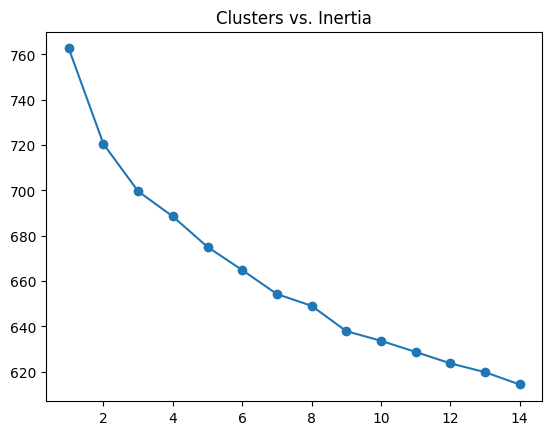

In [27]:
plt.plot(range(1,15), inertias, marker='o')
plt.title('Clusters vs. Inertia')
plt.show()

Something between 4 and 6 looks reasonable here. The returns diminish as the the clusters get smaller.

In [28]:
kmeans = KMeans(n_clusters=6, random_state=42)

In [29]:
kmeans.fit_predict(np.vstack(nyt_df['embedding']))

array([0, 5, 3, 3, 0, 0, 3, 3, 0, 2, 1, 1, 1, 5, 1, 4, 1, 1, 3, 4, 3, 0,
       0, 0, 4, 4, 4, 1, 2, 1, 5, 1, 1, 3, 5, 2, 0, 0, 0, 2, 2, 4, 1, 2,
       2, 1, 0, 5, 5, 2, 1, 0, 0, 2, 2, 2, 5, 4, 4, 3, 1, 3, 1, 3, 0, 2,
       5, 0, 0, 3, 4, 1, 1, 1, 1, 3, 5, 3, 5, 3, 2, 2, 2, 4, 0, 2, 2, 2,
       0, 1, 5, 0, 1, 3, 5, 4, 2, 0, 5, 5, 3, 2, 2, 0, 2, 2, 2, 2, 1, 5,
       0, 4, 1, 5, 3, 5, 0, 2, 5, 1, 1, 1, 3, 5, 2, 2, 5, 0, 0, 1, 1, 5,
       5, 3, 5, 4, 1, 4, 1, 1, 3, 1, 5, 4, 2, 2, 1, 2, 2, 5, 5, 5, 3, 2,
       3, 3, 1, 1, 4, 4, 5, 0, 0, 4, 3, 4, 1, 3, 3, 3, 5, 3, 5, 3, 3, 3,
       2, 0, 5, 2, 5, 4, 2, 4, 1, 4, 0, 3, 3, 3, 3, 3, 1, 1, 2, 3, 2, 2,
       2, 2, 2, 4, 3, 5, 2, 3, 4, 1, 2, 2, 5, 2, 2, 2, 4, 5, 2, 5, 5, 5,
       5, 3, 0, 3, 5, 4, 1, 5, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 0, 4,
       4, 2, 4, 2, 1, 1, 4, 5, 0, 5, 1, 5, 3, 1, 3, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 4, 0, 0, 3, 1, 1, 2, 5, 4, 3, 2, 3, 3, 2, 1, 0, 0, 2, 2, 3,
       1, 3, 3, 5, 3, 1, 0, 2, 1, 5, 3, 5, 1, 2, 2,

In [30]:
nyt_df['group'] = kmeans.labels_

In [31]:
nyt_df.head()

,Unnamed: 0,id,human_summary,publication,author,date,year,month,theme,content,tokens,filtered_tokens,embedding,closest_word,closest_word_similarity,group
0,0,17283,In successfully seeking a temporary halt in th...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,politics,WASHINGTON — Congressional Republicans have...,"[washington, congressional, republicans, have,...","[washington, congressional, republicans, new, ...","[-0.003009483916684985, 0.09923268109560013, 0...",obamacare,0.500207,0
1,0,17284,Officers put her in worse danger some months l...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,crime,"After the bullet shells get counted, the blood...","[after, the, bullet, shells, get, counted, the...","[bullet, shells, counted, blood, dries, votive...","[-0.003817687975242734, 0.09933494031429291, 0...",nypd,0.616005,5
2,0,17285,The film striking appearance had been created ...,New York Times,Margalit Fox,2017-01-06,2017.0,1.0,entertainment,"When Walt Disney’s “Bambi” opened in 1942, cri...","[when, walt, disney, s, bambi, opened, in, cri...","[walt, disney, s, bambi, opened, critics, prai...","[-0.003004514379426837, 0.03687206283211708, -...",paintings,0.477135,3
3,0,17286,The year was only days old when the news came ...,New York Times,William McDonald,2017-04-10,2017.0,4.0,entertainment,"Death may be the great equalizer, but it isn’t...","[death, may, be, the, great, equalizer, but, i...","[death, great, equalizer, isn, t, necessarily,...","[0.04948027804493904, 0.10141026973724365, -0....",obituary,0.460346,3
4,0,17287,If North Korea conducts a test in coming month...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,politics,"SEOUL, South Korea — North Korea’s leader, ...","[seoul, south, korea, north, korea, s, leader,...","[seoul, south, korea, north, korea, s, leader,...","[0.049007389694452286, 0.06843918561935425, 0....",pyongyang,0.517894,0


In [32]:
nyt_df.loc[lambda x: x['group'] == 0]['theme'].value_counts()

theme
politics         71
business         44
entertainment     8
law               7
lifestyle         6
science           5
crime             5
technology        3
architecture      1
Name: count, dtype: int64

In [33]:
nyt_df.groupby('group')['theme'].value_counts().to_frame().unstack().fillna(0)

count                                                              \
theme accidents architecture  art business crime entertainment environment    
group                                                                         
0           0.0          1.0  0.0     44.0   5.0           8.0          0.0   
1           1.0          0.0  0.0     37.0  13.0          30.0          1.0   
2           0.0          0.0  0.0     58.0   8.0          16.0          0.0   
3           1.0          0.0  2.0     18.0   9.0          76.0          0.0   
4           1.0          2.0  0.0     30.0  36.0           6.0          0.0   
5           1.0          1.0  0.0     21.0  39.0          17.0          0.0   

                                                                 
theme health   law lifestyle politics science sports technology  
group                                                            
0        0.0   7.0       6.0     71.0     5.0    0.0        3.0  
1        2.0   5.0      33.0     18.0    14.0   20.0        7.0  
2        0.0   5.0       8.0    127.0     1.0    3.0        5.0  
3        0.0   1.0       8.0     21.0     0.0    3.0        2.0  
4        0.0  10.0       7.0     63.0     1.0    4.0        0.0  
5        0.0  13.0      16.0     24.0     3.0    0.0        1.0

In [34]:
nyt_df.groupby('group')['closest_word'].value_counts().to_frame()[lambda x: x['count']>= 5]

count
group closest_word           
0     obamacare            14
      nafta                13
      climategate           8
      indictments           8
      trumponomics          8
      vetoes                8
      brexit                5
      globalism             5
      multilateralism       5
2     inaugurations        13
      manafort              9
      indictments           8
      snowden               8
      inauguration          6
      putin                 5
      tillerson             5
      trumponomics          5
3     fashion               9
      oscars                8
      broadway              6
4     deportations          9
      counterterrorism      8
      refugee               7
      refugees              6
      detainees             5
      diplomacy             5
      islamization          5
      scotus                5
5     protesters            6
      abortion              5
      conviction            5

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
grouped = nyt_df.groupby('group')['filtered_tokens'].apply(lambda x: sum(x, [])).reset_index()

In [37]:
vectorizer = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x)  # Disable default string processing
X = vectorizer.fit_transform(grouped['filtered_tokens'])

/Users/johntemplon/cuny/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [38]:
count_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(), index=grouped['group'])

In [39]:
count_df.T.loc['mr']

group
0    0.466214
1    0.171896
2    0.557608
3    0.323733
4    0.436825
5    0.292800
Name: mr, dtype: float64

In [40]:
word_tfidf = count_df.T

In [41]:
word_tfidf['group_1_2_diff'] = word_tfidf.apply(lambda x: abs(x[1] - x[2]), axis=1)

In [42]:
word_tfidf.sort_values('group_1_2_diff', ascending=False).head(20)

group,0,1,2,3,4,5,group_1_2_diff
mr,0.466214,0.171896,0.557608,0.323733,0.436825,0.292800,0.385712
trump,0.292447,0.009308,0.365201,0.051082,0.171771,0.060734,0.355892
said,0.323418,0.435014,0.298352,0.286699,0.438831,0.504729,0.136662
president,0.112061,0.018927,0.143839,0.026499,0.117858,0.039317,0.124911
s,0.522244,0.605979,0.506371,0.687693,0.475693,0.521670,0.099608
like,0.058868,0.148314,0.052438,0.125790,0.046140,0.093018,0.095876
t,0.075653,0.159174,0.071786,0.140476,0.049901,0.136811,0.087388
new,0.116553,0.160415,0.082060,0.130579,0.089020,0.114755,0.078355
dr,0.008275,0.072296,0.008139,0.003512,0.014544,0.023654,0.064156
years,0.060759,0.099290,0.037761,0.079177,0.058176,0.086625,0.061529


## Fun Word2Vec Math

In [43]:
filename = 'GoogleNews-vectors-negative300.bin'
google_model = KeyedVectors.load_word2vec_format(filename, binary=True)

In [44]:
result = google_model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)

In [45]:
result

[('queen', 0.7118192911148071)]

In [46]:
google_model.most_similar(positive=['women', 'kings'], negative=['men'], topn=1)

[('queens', 0.5838640332221985)]

----

----

----